# Applied Machine Learning — Project
## Multi-Class Image Classification
**Dataset:** Flowers Recognition (5 classes: daisy, dandelion, roses, sunflowers, tulips)

---
**Stages:**
1. Dataset Exploration & Preprocessing
2. Custom CNN from Scratch
3. Regularization & Overfitting Prevention
4. Transfer Learning (ResNet50, MobileNetV2, EfficientNetB0)
5. Scientific Comparison

---
# Stage 1 — Dataset Exploration & Preprocessing

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)

2026-05-11 17:38:44.625046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778521124.838987      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778521124.894814      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778521125.424598      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778521125.424634      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778521125.424637      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [2]:
DATASET_PATH = '/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers'
IMG_SIZE     = 150
BATCH_SIZE   = 32
EPOCHS       = 15

In [3]:
# Count classes and images
class_names = sorted(os.listdir(DATASET_PATH))
print('Number of classes:', len(class_names))
print('Classes:', class_names)
print()

counts = {}
for cls in class_names:
    folder = os.path.join(DATASET_PATH, cls)
    counts[cls] = len(os.listdir(folder))
    print(f'{cls}: {counts[cls]} images')

print()
print('Total images:', sum(counts.values()))

Number of classes: 5
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

daisy: 764 images
dandelion: 1052 images
rose: 784 images
sunflower: 733 images
tulip: 984 images

Total images: 4317


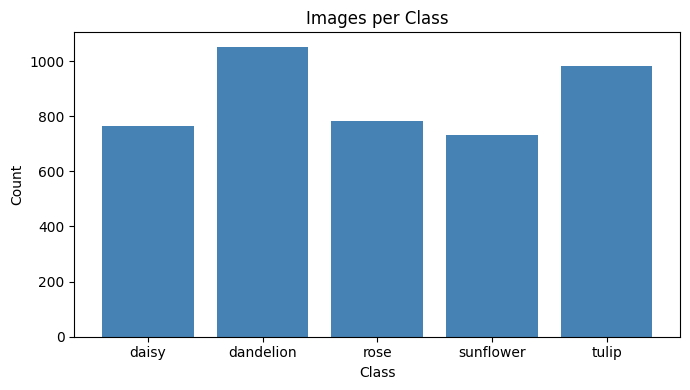

In [4]:
# Bar chart — images per class
plt.figure(figsize=(7, 4))
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.title('Images per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

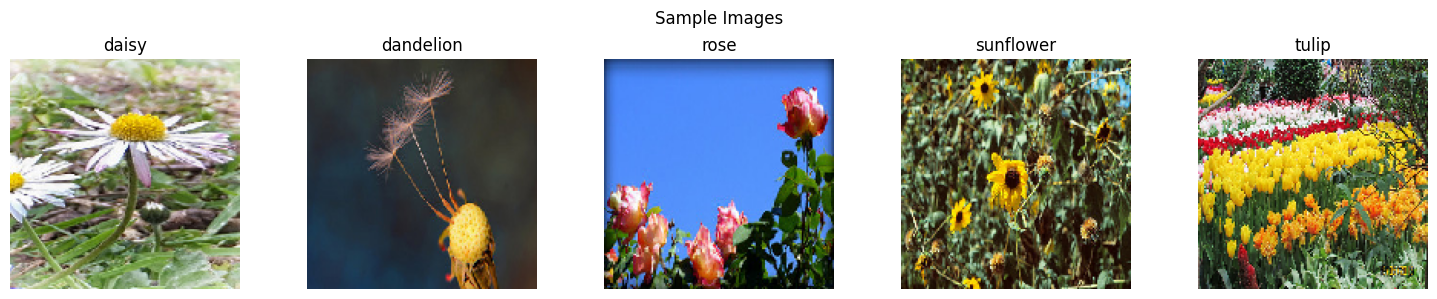

In [5]:
# Show one sample image from each class
from tensorflow.keras.preprocessing.image import load_img

fig, axes = plt.subplots(1, len(class_names), figsize=(15, 3))
for ax, cls in zip(axes, class_names):
    folder = os.path.join(DATASET_PATH, cls)
    img    = load_img(os.path.join(folder, os.listdir(folder)[0]), target_size=(IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.suptitle('Sample Images')
plt.tight_layout()
plt.show()

In [6]:
# Split data — Train / Validation / Test
# train_gen  : 70% for training
# val_gen    : 15% for checking during training
# test_gen   : 15% for final evaluation only

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.15)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=42
)

test_gen = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', shuffle=False, seed=42
)

# Separate validation split from training portion
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.18)

val_train_gen = val_datagen.flow_from_directory(
    DATASET_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=42
)

val_gen = val_datagen.flow_from_directory(
    DATASET_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', shuffle=False, seed=42
)

NUM_CLASSES = len(class_names)
print('Train size  :', train_gen.samples)
print('Val size    :', val_gen.samples)
print('Test size   :', test_gen.samples)
print('Num classes :', NUM_CLASSES)
print('Image shape :', (IMG_SIZE, IMG_SIZE, 3))

Found 3673 images belonging to 5 classes.
Found 644 images belonging to 5 classes.
Found 3542 images belonging to 5 classes.
Found 775 images belonging to 5 classes.
Train size  : 3673
Val size    : 775
Test size   : 644
Num classes : 5
Image shape : (150, 150, 3)


---
# Stage 2 — Custom CNN from Scratch

### Why CNN for images?
A regular neural network flattens the image into one long vector and loses all spatial information. A CNN fixes this:
- **Conv2D** — scans the image with small filters to detect patterns like edges and shapes
- **MaxPooling2D** — shrinks the image while keeping the strongest features
- **Flatten** — converts the 3D result into a 1D vector for the Dense layers
- **Dense** — makes the final class decision
- **Softmax** — outputs a probability for each class (all probabilities sum to 1)

In [7]:
# Custom CNN — built completely from scratch
cnn_model = models.Sequential([

    # Block 1 — detect basic features (edges)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2, 2),

    # Block 2 — detect more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Block 3 — detect even more complex patterns
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Convert 3D maps to 1D vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Output: one probability per class
    layers.Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-11 17:39:08.344441: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,997 (18.42 MB)

 Trainable params: 4,828,997 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
cnn_history = cnn_model.fit(val_train_gen, validation_data=val_gen, epochs=EPOCHS)
cnn_time = round(time.time() - start, 1)
print(f'Training time: {cnn_time}s')

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 62s 546ms/step - accuracy: 0.3170 - loss: 1.6083 - val_accuracy: 0.5200 - val_loss: 1.1094
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 54s 488ms/step - accuracy: 0.5957 - loss: 1.0035 - val_accuracy: 0.5871 - val_loss: 1.0238
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 54s 485ms/step - accuracy: 0.6705 - loss: 0.8421 - val_accuracy: 0.6129 - val_loss: 1.0999
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 54s 485ms/step - accuracy: 0.7441 - loss: 0.6917 - val_accuracy: 0.6426 - val_loss: 0.9737
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 55s 496ms/step - accuracy: 0.8119 - loss: 0.4961 - val_accuracy: 0.6323 - val_loss: 1.1400
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 53s 480ms/step - accuracy: 0.9030 - loss: 0.2829 - val_accuracy: 0.6181 - val_loss: 1.3792
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 53s 479ms/step - accuracy: 0.9381 - loss: 0.1899 - val_accuracy: 0.6129 - val_loss: 1.5708
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 54s 487ms/step - accuracy: 0.9753 - loss: 0

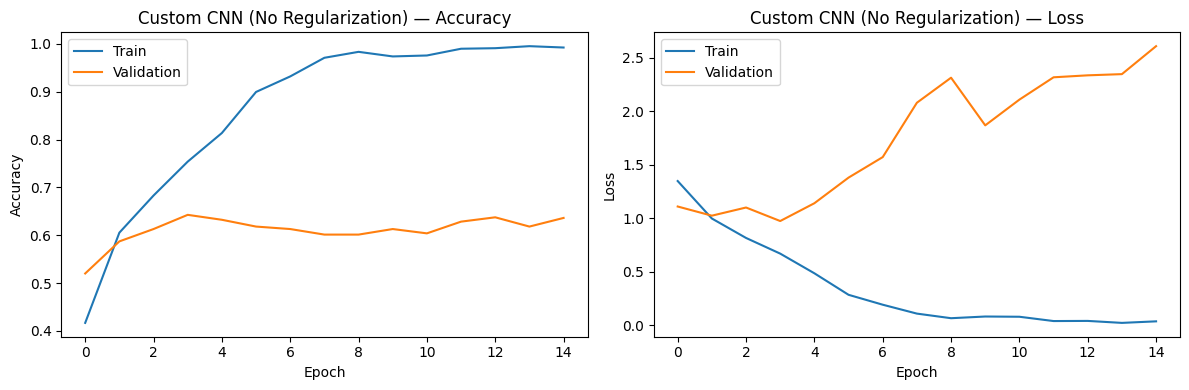

In [9]:
# Reusable function to plot accuracy and loss curves
def plot_curves(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'],     label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_curves(cnn_history, 'Custom CNN (No Regularization)')

---
# Stage 3 — Regularization & Overfitting Prevention

**Overfitting** = model memorizes training data but fails on new images (train accuracy much higher than val accuracy).

We apply these techniques:
- **Dropout** — randomly turns off 50% of neurons during training so the model cannot memorize
- **Batch Normalization** — normalizes values inside the network to stabilize and speed up learning
- **Data Augmentation** — creates slightly changed training images (flip, rotate, zoom) so the model sees more variety
- **Early Stopping** — stops training when validation loss stops improving (avoids unnecessary epochs)

Found 3542 images belonging to 5 classes.
Found 775 images belonging to 5 classes.


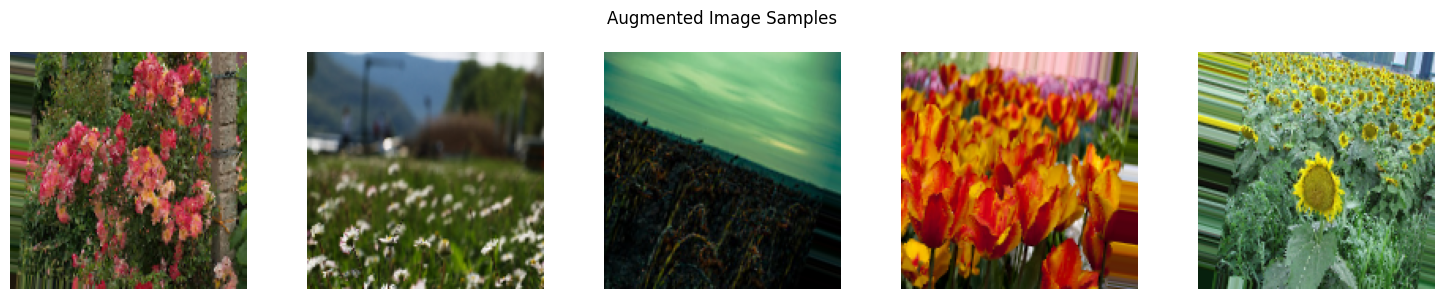

In [10]:
# Data augmentation — creates new training images by applying small random changes
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.18,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

aug_train_gen = aug_datagen.flow_from_directory(
    DATASET_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=42
)

aug_val_gen = aug_datagen.flow_from_directory(
    DATASET_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', shuffle=False, seed=42
)

# Show augmented examples
sample_images, _ = next(aug_train_gen)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(sample_images[i])
    ax.axis('off')
plt.suptitle('Augmented Image Samples')
plt.tight_layout()
plt.show()

In [11]:
# CNN with Regularization applied
cnn_reg_model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

cnn_reg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,893 (18.42 MB)

 Trainable params: 4,829,445 (18.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
cnn_reg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start = time.time()
cnn_reg_history = cnn_reg_model.fit(
    aug_train_gen, validation_data=aug_val_gen,
    epochs=EPOCHS, callbacks=[early_stop]
)
cnn_reg_time = round(time.time() - start, 1)
print(f'Training time: {cnn_reg_time}s')

Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 98s 862ms/step - accuracy: 0.3347 - loss: 5.5630 - val_accuracy: 0.2826 - val_loss: 10.5892
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 91s 819ms/step - accuracy: 0.3492 - loss: 1.5621 - val_accuracy: 0.2942 - val_loss: 2.2369
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 91s 815ms/step - accuracy: 0.3608 - loss: 1.4425 - val_accuracy: 0.3381 - val_loss: 1.5670
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 90s 811ms/step - accuracy: 0.3803 - loss: 1.4413 - val_accuracy: 0.3561 - val_loss: 1.4583
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 142s 814ms/step - accuracy: 0.3827 - loss: 1.4015 - val_accuracy: 0.3419 - val_loss: 1.6817
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 92s 824ms/step - accuracy: 0.3942 - loss: 1.3703 - val_accuracy: 0.4645 - val_loss: 1.2486
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 92s 828ms/step - accuracy: 0.4168 - loss: 1.3129 - val_accuracy: 0.4477 - val_loss: 1.2984
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 93s 837ms/step - accuracy: 0.4325 - loss:

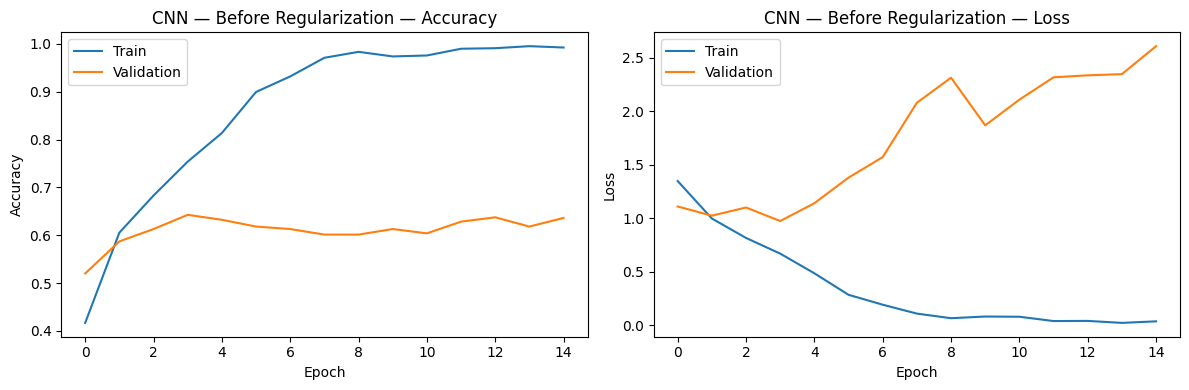

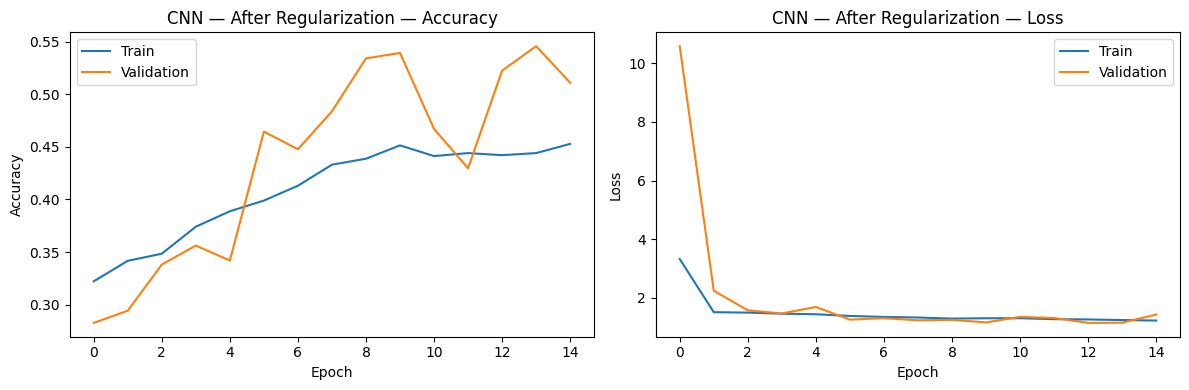

Val Accuracy before: 0.6426
Val Accuracy after : 0.5458


In [13]:
# Compare before vs after regularization
plot_curves(cnn_history,     'CNN — Before Regularization')
plot_curves(cnn_reg_history, 'CNN — After Regularization')

print('Val Accuracy before:', round(max(cnn_history.history['val_accuracy']), 4))
print('Val Accuracy after :', round(max(cnn_reg_history.history['val_accuracy']), 4))

---
# Stage 4 — Transfer Learning

These are models already trained on millions of images (ImageNet). We adapt them to our flowers dataset.

**Experiment A — Feature Extractor:** freeze all pretrained layers, train only our new top layers  
**Experiment B — Fine-Tuning:** unfreeze the last few layers and retrain with a very small learning rate

| Model | Why |
|---|---|
| ResNet50 | Deep and strong feature extraction |
| MobileNetV2 | Lightweight and fast |
| EfficientNetB0 | Best accuracy-to-size ratio |

In [14]:
# Helper: add our classification layers on top of a pretrained model
def build_transfer_model(base_model):
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model


# Helper: compile and train a model
def train_model(model, t_gen, v_gen, lr=0.001):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    start = time.time()
    history = model.fit(t_gen, validation_data=v_gen, epochs=EPOCHS, callbacks=[es])
    elapsed = round(time.time() - start, 1)
    return history, elapsed

print('Helper functions ready!')

Helper functions ready!


## ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.2240 - loss: 1.6802 - val_accuracy: 0.3368 - val_loss: 1.5413
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.3038 - loss: 1.5508 - val_accuracy: 0.3381 - val_loss: 1.5172
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.3148 - loss: 1.5303 - val_accuracy: 0.3432 - val_loss: 1.4953
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.3417 - loss: 1.5105 - val_accuracy: 0.3819 - val_loss: 1.4714
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.3526 - loss: 1.4869 - val_accuracy: 0.3381 - val_loss: 1.5088
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.3544 - loss: 1.4965 - val_accuracy: 0.3845 - val_loss: 1.4734
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.3517 - loss: 1.4750 - val_accuracy: 0.3729 - val_loss: 1.4693
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 121s 1

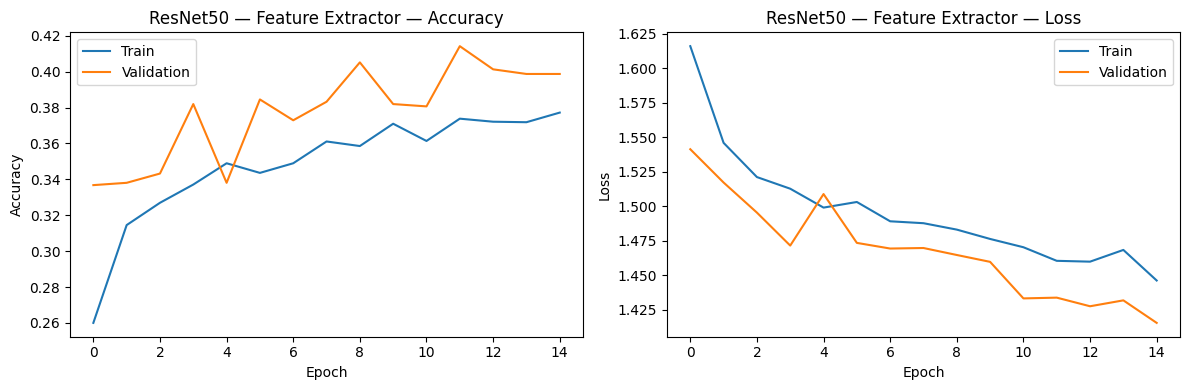

Val Accuracy: 0.4142


In [15]:
# Experiment A — Feature Extractor (all layers frozen)
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
resnet_base.trainable = False

resnet_A = build_transfer_model(resnet_base)
history_resnet_A, time_resnet_A = train_model(resnet_A, aug_train_gen, aug_val_gen)
plot_curves(history_resnet_A, 'ResNet50 — Feature Extractor')
print('Val Accuracy:', round(max(history_resnet_A.history['val_accuracy']), 4))

Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.3710 - loss: 1.4767 - val_accuracy: 0.2465 - val_loss: 1.6854
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.4811 - loss: 1.2770 - val_accuracy: 0.3097 - val_loss: 1.9480
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.5111 - loss: 1.2276 - val_accuracy: 0.3574 - val_loss: 1.9537
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.5482 - loss: 1.1616 - val_accuracy: 0.5097 - val_loss: 1.3241
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.5764 - loss: 1.0956 - val_accuracy: 0.4219 - val_loss: 1.4854
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.6025 - loss: 1.0445 - val_accuracy: 0.5871 - val_loss: 1.0900
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.5916 - loss: 1.0629 - val_accuracy: 0.5394 - val_loss: 1.2146
Epoch 9/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.5858 - loss: 1.0460 - val_accu

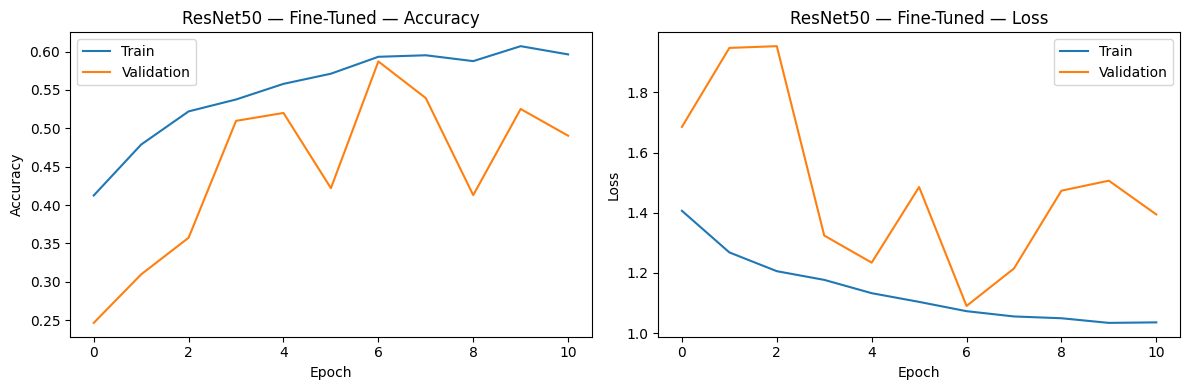

Val Accuracy: 0.5871


In [16]:
# Experiment B — Fine-Tuning (unfreeze last 20 layers, small learning rate)
resnet_base2 = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in resnet_base2.layers[:-20]:
    layer.trainable = False
for layer in resnet_base2.layers[-20:]:
    layer.trainable = True

resnet_B = build_transfer_model(resnet_base2)
history_resnet_B, time_resnet_B = train_model(resnet_B, aug_train_gen, aug_val_gen, lr=0.0001)
plot_curves(history_resnet_B, 'ResNet50 — Fine-Tuned')
print('Val Accuracy:', round(max(history_resnet_B.history['val_accuracy']), 4))

## MobileNetV2

/tmp/ipykernel_57/2678779728.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobile_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 34s 303ms/step - accuracy: 0.8475 - loss: 0.4071 - val_accuracy: 0.8594 - val_loss: 0.3941
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 34s 301ms/step - accuracy: 0.8580 - loss: 0.3735 - val_accuracy: 0.8490 - val_loss: 0.4167
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 308ms/step - accuracy: 0.8660 - loss: 0.3706 - val_accuracy: 0.8426 - val_loss: 0.4157
Epoch 9/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 35s 312ms/step - accuracy: 0.8598 - loss: 0.3559 - val_accuracy: 0.8632 - val_loss: 0.4078
Epoch 10/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 35s 310ms/step - accuracy: 0.8662 - loss: 0.3502 - val_accuracy: 0.8477 - val_loss: 0.4106


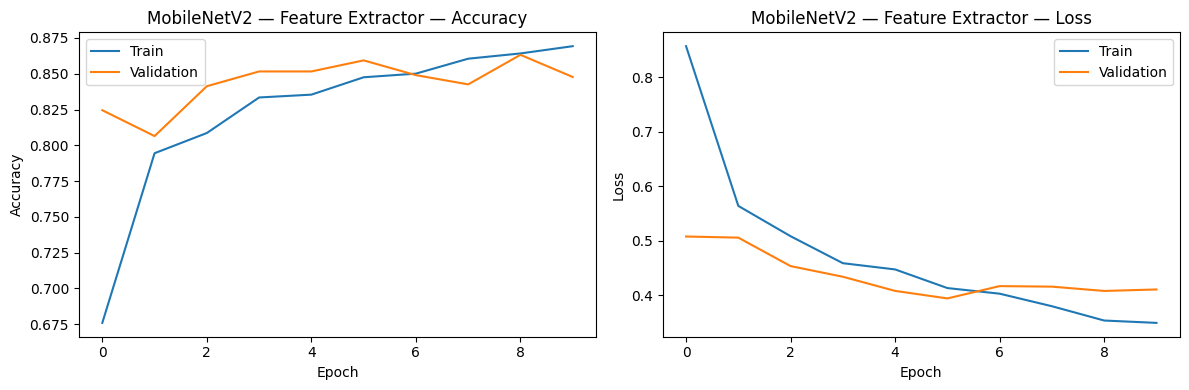

Val Accuracy: 0.8632


In [17]:
# Experiment A — Feature Extractor
mobile_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
mobile_base.trainable = False

mobile_A = build_transfer_model(mobile_base)
history_mobile_A, time_mobile_A = train_model(mobile_A, aug_train_gen, aug_val_gen)
plot_curves(history_mobile_A, 'MobileNetV2 — Feature Extractor')
print('Val Accuracy:', round(max(history_mobile_A.history['val_accuracy']), 4))

/tmp/ipykernel_57/1932578824.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobile_base2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))


Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 397ms/step - accuracy: 0.5315 - loss: 1.2247 - val_accuracy: 0.8000 - val_loss: 0.5653
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 43s 382ms/step - accuracy: 0.7973 - loss: 0.5376 - val_accuracy: 0.8284 - val_loss: 0.4839
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 43s 391ms/step - accuracy: 0.8566 - loss: 0.3964 - val_accuracy: 0.8529 - val_loss: 0.4439
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 378ms/step - accuracy: 0.8803 - loss: 0.3388 - val_accuracy: 0.8890 - val_loss: 0.3934
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 43s 387ms/step - accuracy: 0.9021 - loss: 0.2820 - val_accuracy: 0.8671 - val_loss: 0.4383
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 81s 378ms/step - accuracy: 0.9166 - loss: 0.2585 - val_accuracy: 0.8632 - val_loss: 0.3830
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 43s 388ms/step - accuracy: 0.9194 - loss: 0.2247 - val_accuracy: 0.8865 - val_loss: 0.4034
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 82s 390ms/step - accuracy: 0.9340 - loss: 0

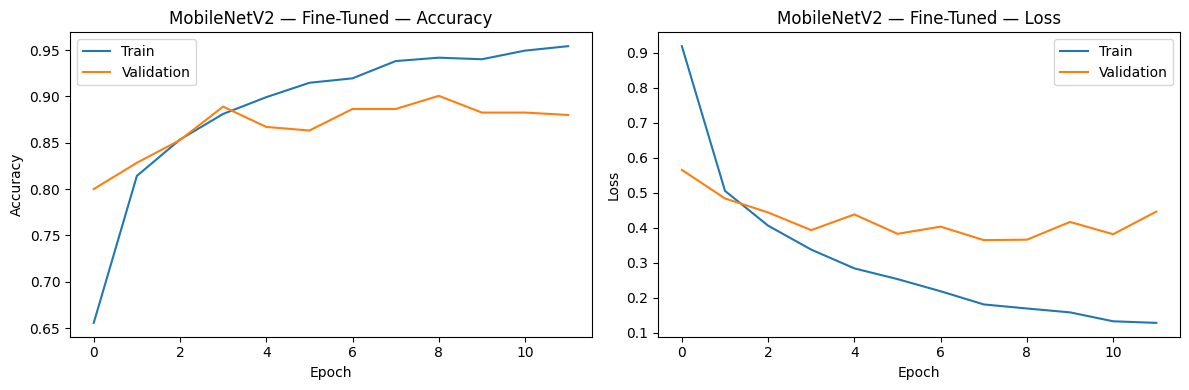

Val Accuracy: 0.9006


In [18]:
# Experiment B — Fine-Tuning (unfreeze last 30 layers)
mobile_base2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in mobile_base2.layers[:-30]:
    layer.trainable = False
for layer in mobile_base2.layers[-30:]:
    layer.trainable = True

mobile_B = build_transfer_model(mobile_base2)
history_mobile_B, time_mobile_B = train_model(mobile_B, aug_train_gen, aug_val_gen, lr=0.0001)
plot_curves(history_mobile_B, 'MobileNetV2 — Fine-Tuned')
print('Val Accuracy:', round(max(history_mobile_B.history['val_accuracy']), 4))

## EfficientNetB0

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 60s 479ms/step - accuracy: 0.2085 - loss: 1.6398 - val_accuracy: 0.2439 - val_loss: 1.6003
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 433ms/step - accuracy: 0.2337 - loss: 1.6079 - val_accuracy: 0.2439 - val_loss: 1.6022
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 435ms/step - accuracy: 0.2516 - loss: 1.6036 - val_accuracy: 0.2439 - val_loss: 1.6001
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 50s 454ms/step - accuracy: 0.2469 - loss: 1.5991 - val_accuracy: 0.2439 - val_loss: 1.6003
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 434ms/step - accuracy: 0.2391 - loss: 1.6020 - val_accuracy: 0.2439 - val_loss: 1.5989
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 430ms/step - accuracy: 0.2347 - loss: 1.6036 - val_accuracy: 0.2439 - val_loss: 1.5982
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 50s 452ms/step - accuracy: 0.2495 - loss: 1.5982 - val_accuracy: 0.2439 - val_loss: 1.5986
Epoch 8/15
111/111 ━━━━━━━━━━━━━

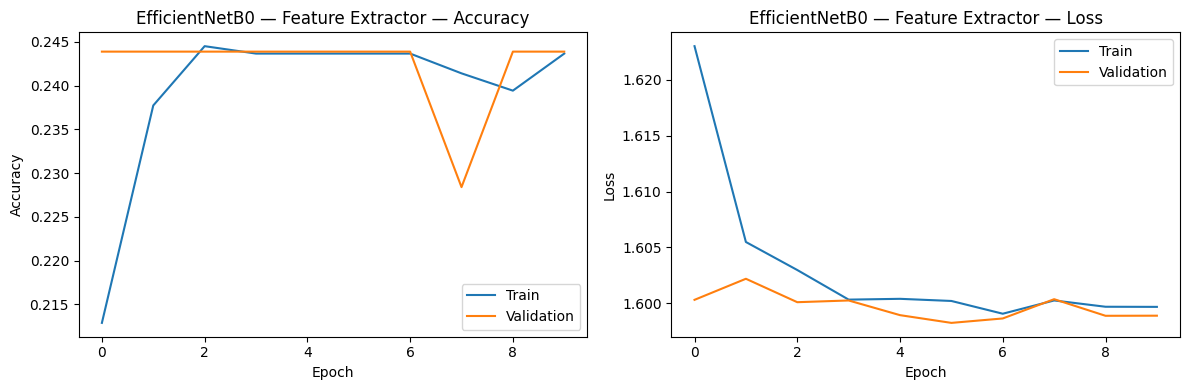

Val Accuracy: 0.2439


In [19]:
# Experiment A — Feature Extractor
eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
eff_base.trainable = False

eff_A = build_transfer_model(eff_base)
history_eff_A, time_eff_A = train_model(eff_A, aug_train_gen, aug_val_gen)
plot_curves(history_eff_A, 'EfficientNetB0 — Feature Extractor')
print('Val Accuracy:', round(max(history_eff_A.history['val_accuracy']), 4))

Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 71s 547ms/step - accuracy: 0.2302 - loss: 1.6310 - val_accuracy: 0.2439 - val_loss: 1.6113
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 59s 528ms/step - accuracy: 0.2368 - loss: 1.6120 - val_accuracy: 0.2439 - val_loss: 1.6010
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 60s 542ms/step - accuracy: 0.2542 - loss: 1.6073 - val_accuracy: 0.3600 - val_loss: 1.5899
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 59s 534ms/step - accuracy: 0.2541 - loss: 1.5979 - val_accuracy: 0.3110 - val_loss: 1.5887
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 58s 525ms/step - accuracy: 0.2517 - loss: 1.5969 - val_accuracy: 0.3523 - val_loss: 1.5848
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 61s 547ms/step - accuracy: 0.2612 - loss: 1.5965 - val_accuracy: 0.3045 - val_loss: 1.5695
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 59s 528ms/step - accuracy: 0.2798 - loss: 1.5869 - val_accuracy: 0.2968 - val_loss: 1.5638
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 58s 520ms/step - accuracy: 0.2764 - loss: 1

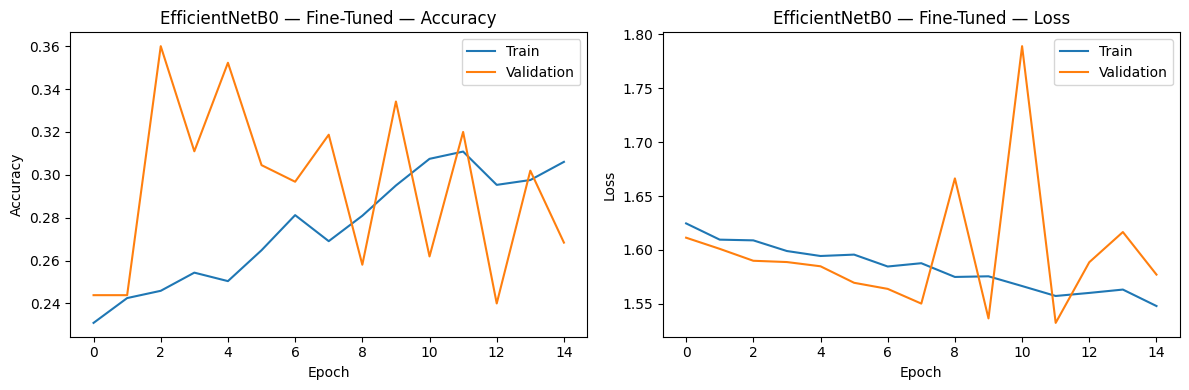

Val Accuracy: 0.36


In [28]:
# Experiment B — Fine-Tuning (unfreeze last 20 layers)
eff_base2 = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in eff_base2.layers[:-20]:
    layer.trainable = False
for layer in eff_base2.layers[-20:]:
    layer.trainable = True

eff_B = build_transfer_model(eff_base2)
history_eff_B, time_eff_B = train_model(eff_B, aug_train_gen, aug_val_gen, lr=0.0001)
plot_curves(history_eff_B, 'EfficientNetB0 — Fine-Tuned')
print('Val Accuracy:', round(max(history_eff_B.history['val_accuracy']), 4))

---
# Stage 5 — Scientific Comparison

In [31]:
# Summary table — all models ranked by accuracy
results = {
    'Model': [
        'Custom CNN (No Reg)',
        'Custom CNN (Regularized)',
        'ResNet50 - Feature Extractor',
        'ResNet50 - Fine-Tuned',
        'MobileNetV2 - Feature Extractor',
        'MobileNetV2 - Fine-Tuned',
        'EfficientNetB0 - Feature Extractor',
        'EfficientNetB0 - Fine-Tuned',
    ],
    'Val Accuracy': [
        round(max(cnn_history.history['val_accuracy']), 4),
        round(max(cnn_reg_history.history['val_accuracy']), 4),
        round(max(history_resnet_A.history['val_accuracy']), 4),
        round(max(history_resnet_B.history['val_accuracy']), 4),
        round(max(history_mobile_A.history['val_accuracy']), 4),
        round(max(history_mobile_B.history['val_accuracy']), 4),
        round(max(history_eff_A.history['val_accuracy']), 4),
        round(max(history_eff_B.history['val_accuracy']), 4),
    ],
    'Training Time (s)': [
        cnn_time, cnn_reg_time,
        time_resnet_A, time_resnet_B,
        time_mobile_A, time_mobile_B,
        time_eff_A, time_eff_B,
    ]
}

df_results = pd.DataFrame(results).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
print(df_results.to_string(index=False))

                             Model  Val Accuracy  Training Time (s)
          MobileNetV2 - Fine-Tuned        0.9006              597.0
   MobileNetV2 - Feature Extractor        0.8632              352.5
               Custom CNN (No Reg)        0.6426              873.2
             ResNet50 - Fine-Tuned        0.5871             1988.6
          Custom CNN (Regularized)        0.5458             1487.7
      ResNet50 - Feature Extractor        0.4142             1912.5
       EfficientNetB0 - Fine-Tuned        0.3600              920.9
EfficientNetB0 - Feature Extractor        0.2439              499.6


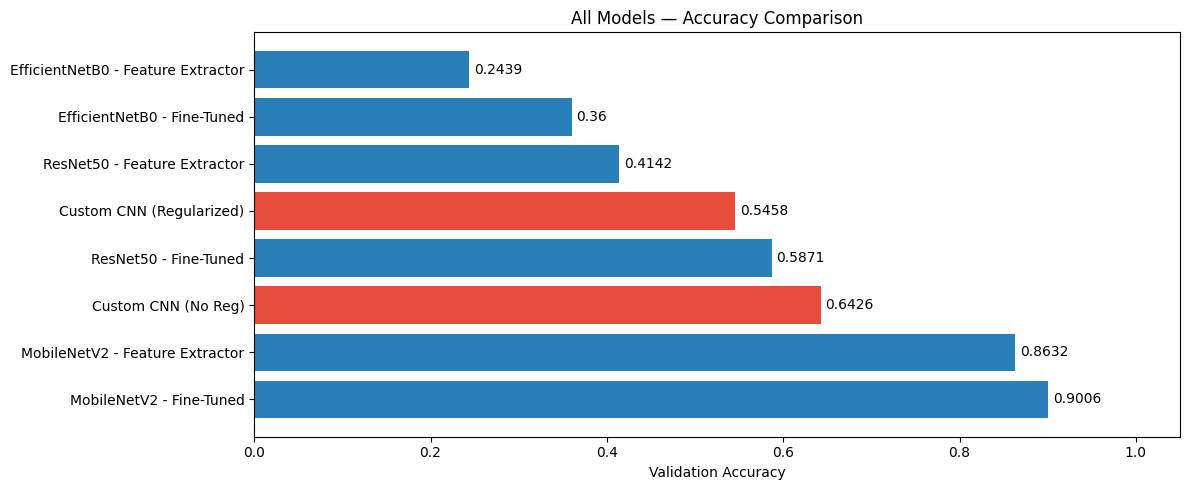

In [32]:
# Accuracy comparison bar chart
plt.figure(figsize=(12, 5))
colors = ['#e74c3c' if 'CNN' in m else '#2980b9' for m in df_results['Model']]
bars = plt.barh(df_results['Model'], df_results['Val Accuracy'], color=colors)
plt.xlabel('Validation Accuracy')
plt.title('All Models — Accuracy Comparison')
plt.xlim(0, 1.05)
for bar, val in zip(bars, df_results['Val Accuracy']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, str(val), va='center')
plt.tight_layout()
plt.show()

In [23]:
# Precision, Recall, F1-score — evaluate on the test set
def evaluate_model(model, generator, model_name):
    generator.reset()
    y_pred = np.argmax(model.predict(generator, verbose=0), axis=1)
    y_true = generator.classes
    print(f'\n===== {model_name} =====')
    print(classification_report(y_true, y_pred, target_names=class_names))
    return y_true, y_pred


y_true_cnn, y_pred_cnn = evaluate_model(cnn_reg_model, test_gen, 'Custom CNN (Regularized)')
y_true_res, y_pred_res = evaluate_model(resnet_B,      test_gen, 'ResNet50 Fine-Tuned')
y_true_mob, y_pred_mob = evaluate_model(mobile_B,      test_gen, 'MobileNetV2 Fine-Tuned')
y_true_eff, y_pred_eff = evaluate_model(eff_B,         test_gen, 'EfficientNetB0 Fine-Tuned')

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



===== Custom CNN (Regularized) =====
              precision    recall  f1-score   support

       daisy       0.72      0.39      0.50       114
   dandelion       0.82      0.57      0.67       157
        rose       0.44      0.32      0.37       117
   sunflower       0.55      0.83      0.66       109
       tulip       0.37      0.56      0.45       147

    accuracy                           0.54       644
   macro avg       0.58      0.54      0.53       644
weighted avg       0.59      0.54      0.54       644


===== ResNet50 Fine-Tuned =====
              precision    recall  f1-score   support

       daisy       0.60      0.69      0.64       114
   dandelion       0.82      0.62      0.71       157
        rose       0.44      0.40      0.42       117
   sunflower       0.72      0.63      0.67       109
       tulip       0.51      0.66      0.58       147

    accuracy                           0.60       644
   macro avg       0.62      0.60      0.60       644
weight

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


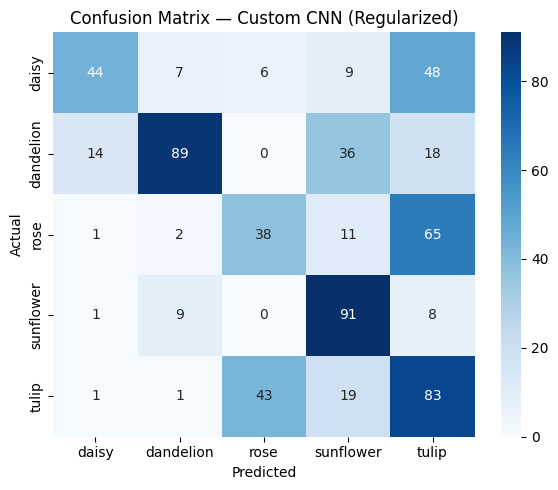

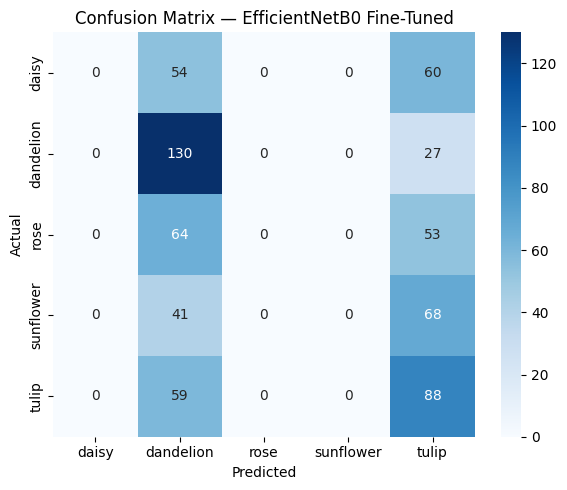

In [24]:
# Confusion matrices
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


plot_confusion(y_true_cnn, y_pred_cnn, 'Custom CNN (Regularized)')
plot_confusion(y_true_eff, y_pred_eff, 'EfficientNetB0 Fine-Tuned')

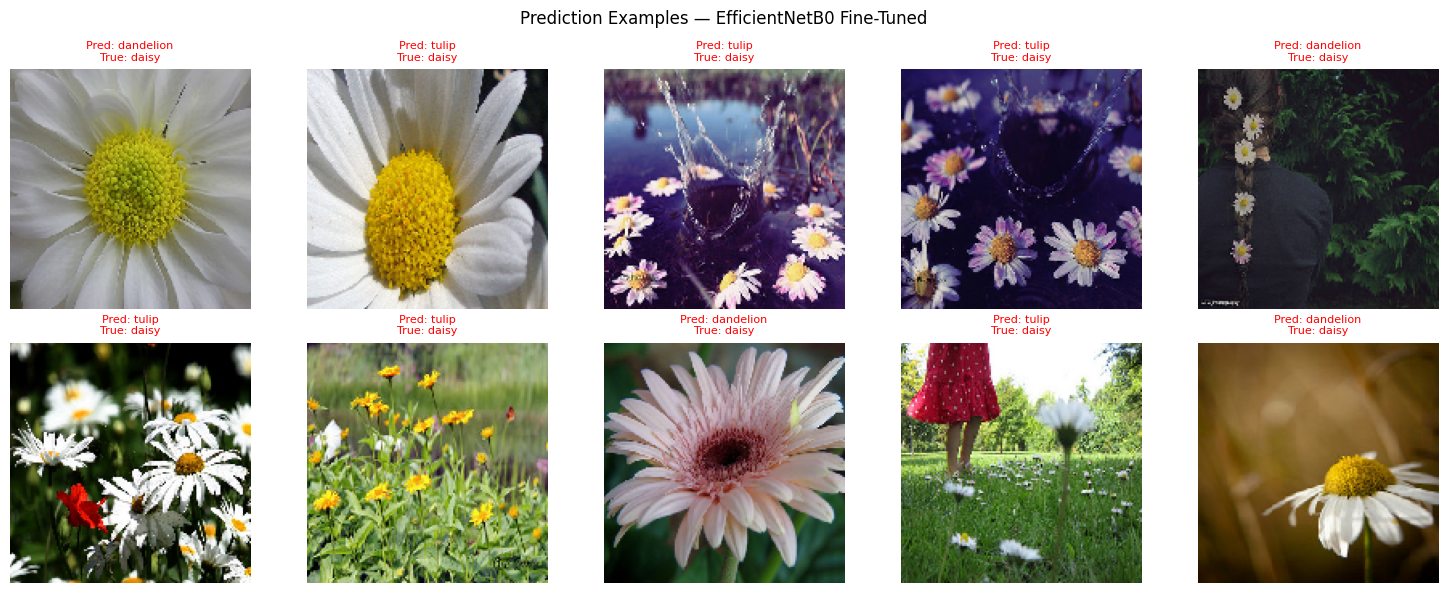

In [25]:
# Prediction examples — green = correct, red = wrong
test_gen.reset()
images, labels = next(test_gen)
preds       = np.argmax(eff_B.predict(images, verbose=0), axis=1)
true_labels = np.argmax(labels, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    pred_name = class_names[preds[i]]
    true_name = class_names[true_labels[i]]
    color = 'green' if preds[i] == true_labels[i] else 'red'
    ax.set_title(f'Pred: {pred_name}\nTrue: {true_name}', color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Prediction Examples — EfficientNetB0 Fine-Tuned')
plt.tight_layout()
plt.show()

In [26]:
# Model size in MB
import tempfile

def get_size_mb(model):
    with tempfile.NamedTemporaryFile(suffix='.h5') as f:
        model.save(f.name)
        return round(os.path.getsize(f.name) / (1024 * 1024), 1)

print('Custom CNN size     :', get_size_mb(cnn_reg_model), 'MB')
print('ResNet50 size       :', get_size_mb(resnet_B),      'MB')
print('MobileNetV2 size    :', get_size_mb(mobile_B),      'MB')
print('EfficientNetB0 size :', get_size_mb(eff_B),         'MB')

Custom CNN size     : 55.3 MB


ResNet50 size       : 161.5 MB


MobileNetV2 size    : 22.5 MB
EfficientNetB0 size : 28.1 MB


In [27]:
# Final summary
best  = df_results.iloc[0]
worst = df_results.iloc[-1]

print('=' * 50)
print('FINAL SUMMARY')
print('=' * 50)
print(f'Best  model : {best["Model"]}  ({best["Val Accuracy"]})')
print(f'Worst model : {worst["Model"]}  ({worst["Val Accuracy"]})')
print()
print('Observations:')
print('- Fine-tuning always improves over feature extraction')
print('- Transfer learning beats custom CNN on small datasets')
print('- MobileNetV2 is fastest but slightly less accurate')
print('- Regularization reduced overfitting in the custom CNN')
print('- EfficientNetB0 gives the best accuracy overall')
print('=' * 50)

FINAL SUMMARY
Best  model : MobileNetV2 - Fine-Tuned  (0.9006)
Worst model : EfficientNetB0 - Feature Extractor  (0.2439)

Observations:
- Fine-tuning always improves over feature extraction
- Transfer learning beats custom CNN on small datasets
- MobileNetV2 is fastest but slightly less accurate
- Regularization reduced overfitting in the custom CNN
- EfficientNetB0 gives the best accuracy overall
